### Rolling erraticness score with hysterisis thresholding


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
import pandas as pd
from scipy.ndimage import uniform_filter1d
from skimage.filters import apply_hysteresis_threshold

In [30]:
# Data 
x = np.load('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0070_1C_4N_E3_8/data/Clip0070_1C_4N_E3_8_id3/X#wcentroid.npy')
print(x.shape)
y = np.load('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0070_1C_4N_E3_8/data/Clip0070_1C_4N_E3_8_id3/Y#wcentroid.npy')
print(x.shape)

# infs -> nan
x[np.isinf(x)] = np.nan
y[np.isinf(y)] = np.nan

vel_x = np.gradient(x)
vel_y = np.gradient(y)

vel = np.zeros((x.shape[0], 2))

vel[:,0] = vel_x
vel[:,1] = vel_y

speed = np.linalg.norm(vel, axis=1, ord=2)
acceleration = np.gradient(speed)
accel_threshold = 0.3

(1882,)
(1882,)


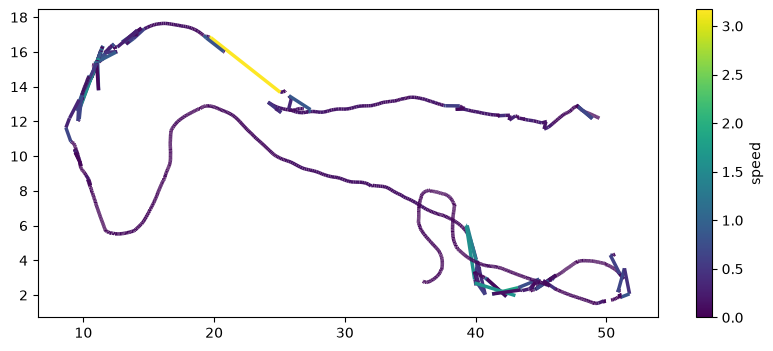

In [31]:
# raw trajectory with speed
segment_speeds = speed[:-1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

l = 10
fig, ax = plt.subplots(figsize = (l, l*(20/50)))
lc = LineCollection(segments, cmap='viridis')
lc.set_array(segment_speeds)
lc.set_linewidth(2.5)

line = ax.add_collection(lc)

fig.colorbar(line, ax=ax, label="speed")
ax.autoscale()
plt.show()

In [19]:

# # finding distances
# positions = np.vstack((x, y)) # (2, 1882)
# diff = np.diff(positions, axis=1)
# d = np.linalg.norm(diff, axis=0, ord=2)
# # plt.hist(d)
# med = np.nanmedian(d)
# mad = np.nanmedian(np.abs(d - med))
# S = max(med + 1.4826*mad, 1e-9)

# # Step-size factor
# A = np.minimum(d[:-1], d[1:])/S
# A = np.minimum(A, 3)
# # reversal factor

# dot_prod = np.sum(diff[:,1:]*diff[:,:-1], axis=0)
# denominator = d[:-1]*d[1:]
# valid_step = ~np.isnan(denominator)

# safe_mask = (denominator > 0)
# cos_theta = np.zeros(dot_prod.shape[0])
# cos_theta[safe_mask] = dot_prod[safe_mask]/denominator[safe_mask]
# cos_theta = np.clip(cos_theta, -1.0, 1.0)

# # R = (1-cos_theta_new)/2
# R = np.full(dot_prod.shape, np.nan)
# R[valid_step] = 0.0                              # zero-length step: not reversing
# R[safe_mask] = (1 - cos_theta[safe_mask]) / 2


# # erratic score
# e = A*R
# e_full = np.full(x.shape[0], np.nan)
# e_full[1:-1] = e

# # e threshold
# k = 7
# valid = ~np.isnan(e_full)
# num = uniform_filter1d(np.where(valid, e_full, 0.0), size=k, mode='constant', cval=0.0)
# den = uniform_filter1d(valid.astype(float), size=k, mode='constant', cval=0.0)

# E = np.full(x.shape[0], np.nan)
# E[den > 0] = num[den > 0] / den[den > 0]

# E_filled = np.nan_to_num(E, nan=0.0) 
# # E = uniform_filter1d(e, size=k, mode='nearest')

In [20]:
# plt.plot(range(len(A[656:726])), A[656:726], label='A')
# plt.plot(range(len(R[656:726])), R[656:726], label='R')
# # plt.xticks(range(len(R[656, 726])), range(656, 726))
# plt.legend()


In [21]:
# low, high = 0.05, 0.6
# plt.close()
# plt.figure(figsize=(10,4))
# plt.plot(range(len(E)), E)
# plt.axhline(y = low, color='red', linestyle='--')
# plt.axhline(y = high, color='green', linestyle='--')
# # plt.axvline(x=656)
# # plt.axvline(x=726)
# # plt.xlim(630, 750)
# plt.show()

In [22]:


# E[np.isnan(E)] = 0

# hyst_mask = apply_hysteresis_threshold(E, low, high)

# x_clean = x.copy()
# y_clean = y.copy()

# x_clean[hyst_mask] = np.nan
# y_clean[hyst_mask] = np.nan

# plt.close()
# plt.plot(x, y, alpha=0.5)
# plt.plot(x_clean, y_clean, color='black')

# plt.show()

In [32]:
x_anchors = x.copy()
y_anchors = y.copy()

# calculating lenghts of contiguous nans
x_non_nan_idx = np.where(~np.isnan(x_anchors))[0]
y_non_nan_idx = np.where(~np.isnan(y_anchors))[0]
padding_x = np.hstack(([-1], x_non_nan_idx, [len(x_non_nan_idx)]))
padding_y = np.hstack(([-1], y_non_nan_idx, [len(y_non_nan_idx)]))

d_x = np.diff(x_non_nan_idx)
d_y = np.diff(y_non_nan_idx)

lengths_of_nans_x = d_x[d_x>1]-1
lengths_of_nans_y = d_y[d_y>1]-1

print(max(lengths_of_nans_x), max(lengths_of_nans_y))
# print(d_x)

11 11


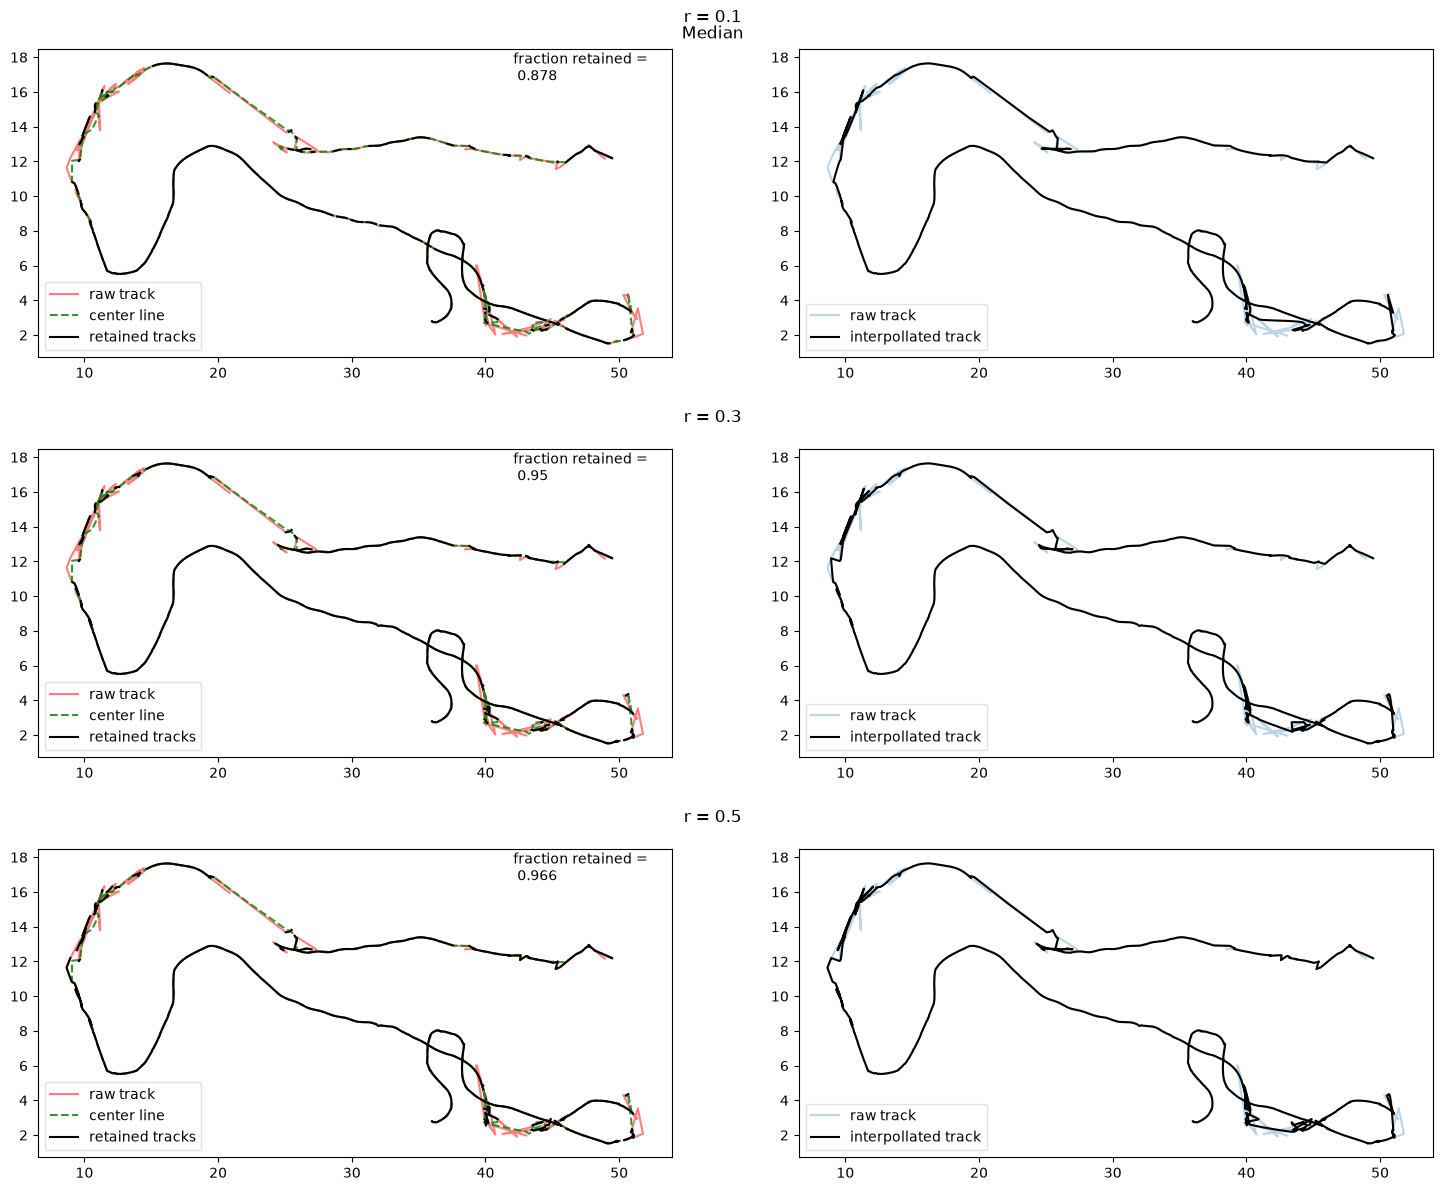

In [33]:
# Median smoothening

k = 8
med_filtered_x = pd.Series(x).rolling(window=k, min_periods=1, center=True).median().to_numpy()
med_filtered_y = pd.Series(y).rolling(window=k, min_periods=1, center=True).median().to_numpy()

r_all = [0.1, 0.3, 0.5]

fig = plt.figure(figsize=(18,12))
subfigs = fig.subfigures(len(r_all), 1)

median_dist_cl = np.zeros(len(x))
fig.suptitle("Median")

for i, subfig in enumerate(subfigs):
    r = r_all[i]
    center_line = np.vstack((med_filtered_x, med_filtered_y))
    clean_pos = np.vstack((x, y))

    dist_from_cl = clean_pos - center_line
    dist_from_cl = np.linalg.norm(dist_from_cl, axis=0, ord=2)
    median_dist_cl = dist_from_cl
    
    out_of_blanket_mask = (dist_from_cl >= r)
    out_of_blanket_mask[0], out_of_blanket_mask[-1] = False, False

    curr_x_anchors = x.copy()
    curr_y_anchors = y.copy()

    curr_x_anchors[out_of_blanket_mask] = np.nan
    curr_y_anchors[out_of_blanket_mask] = np.nan

    fraction_of_track_retained = 1 - out_of_blanket_mask.sum()/len(x)
    subfig.suptitle(f"r = {r}")
    ax = subfig.subplots(nrows=1, ncols=2)

    ax[0].plot(x, y, color='red', alpha=0.5, label='raw track')
    ax[0].plot(med_filtered_x, med_filtered_y, 'g--', alpha=0.8, label="center line")
    ax[0].plot(curr_x_anchors, curr_y_anchors, color='black', label="retained tracks")
    ax[0].legend(loc="lower left", framealpha=0.6)
    ax[0].text(0.75, 0.9, f"fraction retained = \n {round(fraction_of_track_retained,3)}", transform=ax[0].transAxes)
               
    x_interp_med = pd.Series(curr_x_anchors).interpolate(method='pchip').to_numpy()
    y_interp_med = pd.Series(curr_y_anchors).interpolate(method='pchip').to_numpy()

    ax[1].plot(x, y, alpha=0.3,label= "raw track")
    ax[1].plot(x_interp_med, y_interp_med, color='black', label="interpollated track")
    ax[1].legend(loc="lower left", framealpha=0.6)

# plt.tight_layout()

plt.show()

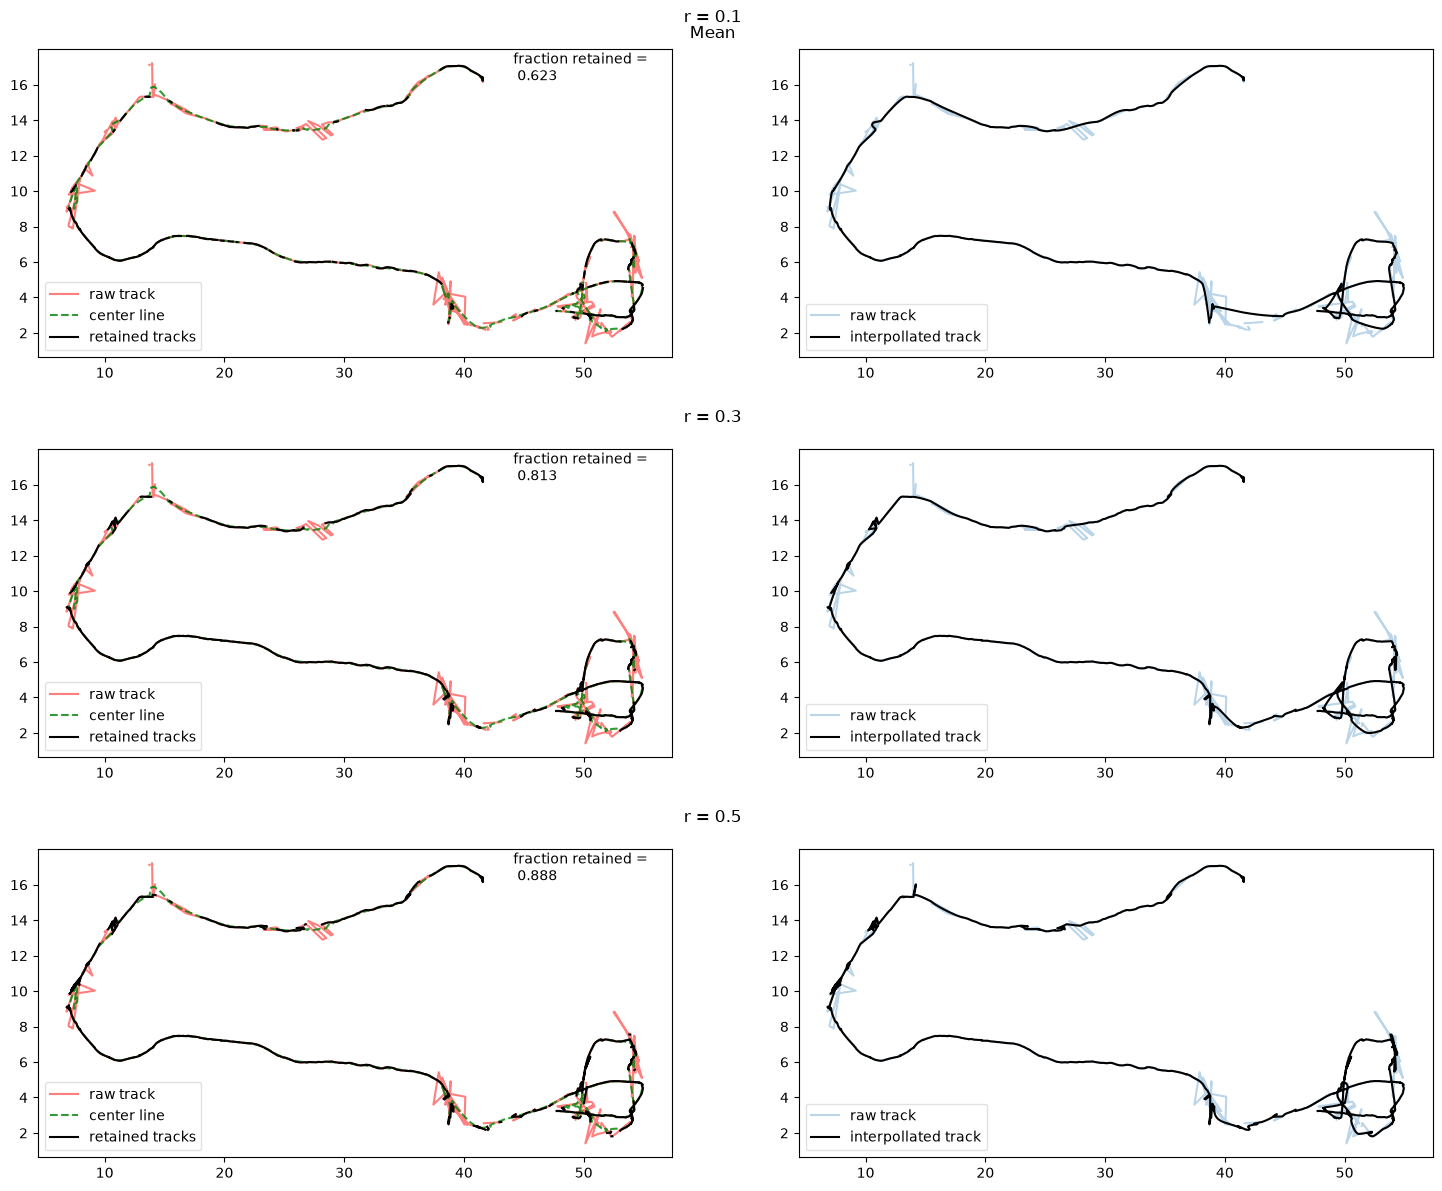

In [25]:
# Mean smoothening
k = 16
med_filtered_x = pd.Series(x).rolling(window=k, min_periods=1, center=True).mean().to_numpy()
med_filtered_y = pd.Series(y).rolling(window=k, min_periods=1, center=True).mean().to_numpy()

r_all = [0.1, 0.3, 0.5]

fig = plt.figure(figsize=(18,12))
subfigs = fig.subfigures(len(r_all), 1)

mean_dist_cl = np.zeros(len(x))
fig.suptitle("Mean")

for i, subfig in enumerate(subfigs):
    r = r_all[i]
    center_line = np.vstack((med_filtered_x, med_filtered_y))
    clean_pos = np.vstack((x, y))

    dist_from_cl = clean_pos - center_line
    dist_from_cl = np.linalg.norm(dist_from_cl, axis=0, ord=2)
    mean_dist_cl = dist_from_cl
    
    out_of_blanket_mask = (dist_from_cl >= r)
    out_of_blanket_mask[0], out_of_blanket_mask[-1] = False, False

    curr_x_anchors = x.copy()
    curr_y_anchors = y.copy()

    curr_x_anchors[out_of_blanket_mask] = np.nan
    curr_y_anchors[out_of_blanket_mask] = np.nan

    subfig.suptitle(f"r = {r}")
    ax = subfig.subplots(nrows=1, ncols=2)
    fraction_of_track_retained = 1 - out_of_blanket_mask.sum()/len(x)

    ax[0].plot(x, y, color='red', alpha=0.5, label='raw track')
    ax[0].plot(med_filtered_x, med_filtered_y, 'g--', alpha=0.8, label="center line")
    ax[0].plot(curr_x_anchors, curr_y_anchors, color='black', label="retained tracks")
    ax[0].legend(loc="lower left", framealpha=0.6)
    ax[0].text(0.75, 0.9, f"fraction retained = \n {round(fraction_of_track_retained,3)}", transform=ax[0].transAxes)
               
    x_interp = pd.Series(curr_x_anchors).interpolate(method='pchip').to_numpy()
    y_interp = pd.Series(curr_y_anchors).interpolate(method='pchip').to_numpy()

    ax[1].plot(x, y, alpha=0.3,label= "raw track")
    ax[1].plot(x_interp, y_interp, color='black', label="interpollated track")
    ax[1].legend(loc="lower left", framealpha=0.6)

# plt.tight_layout()
plt.show()

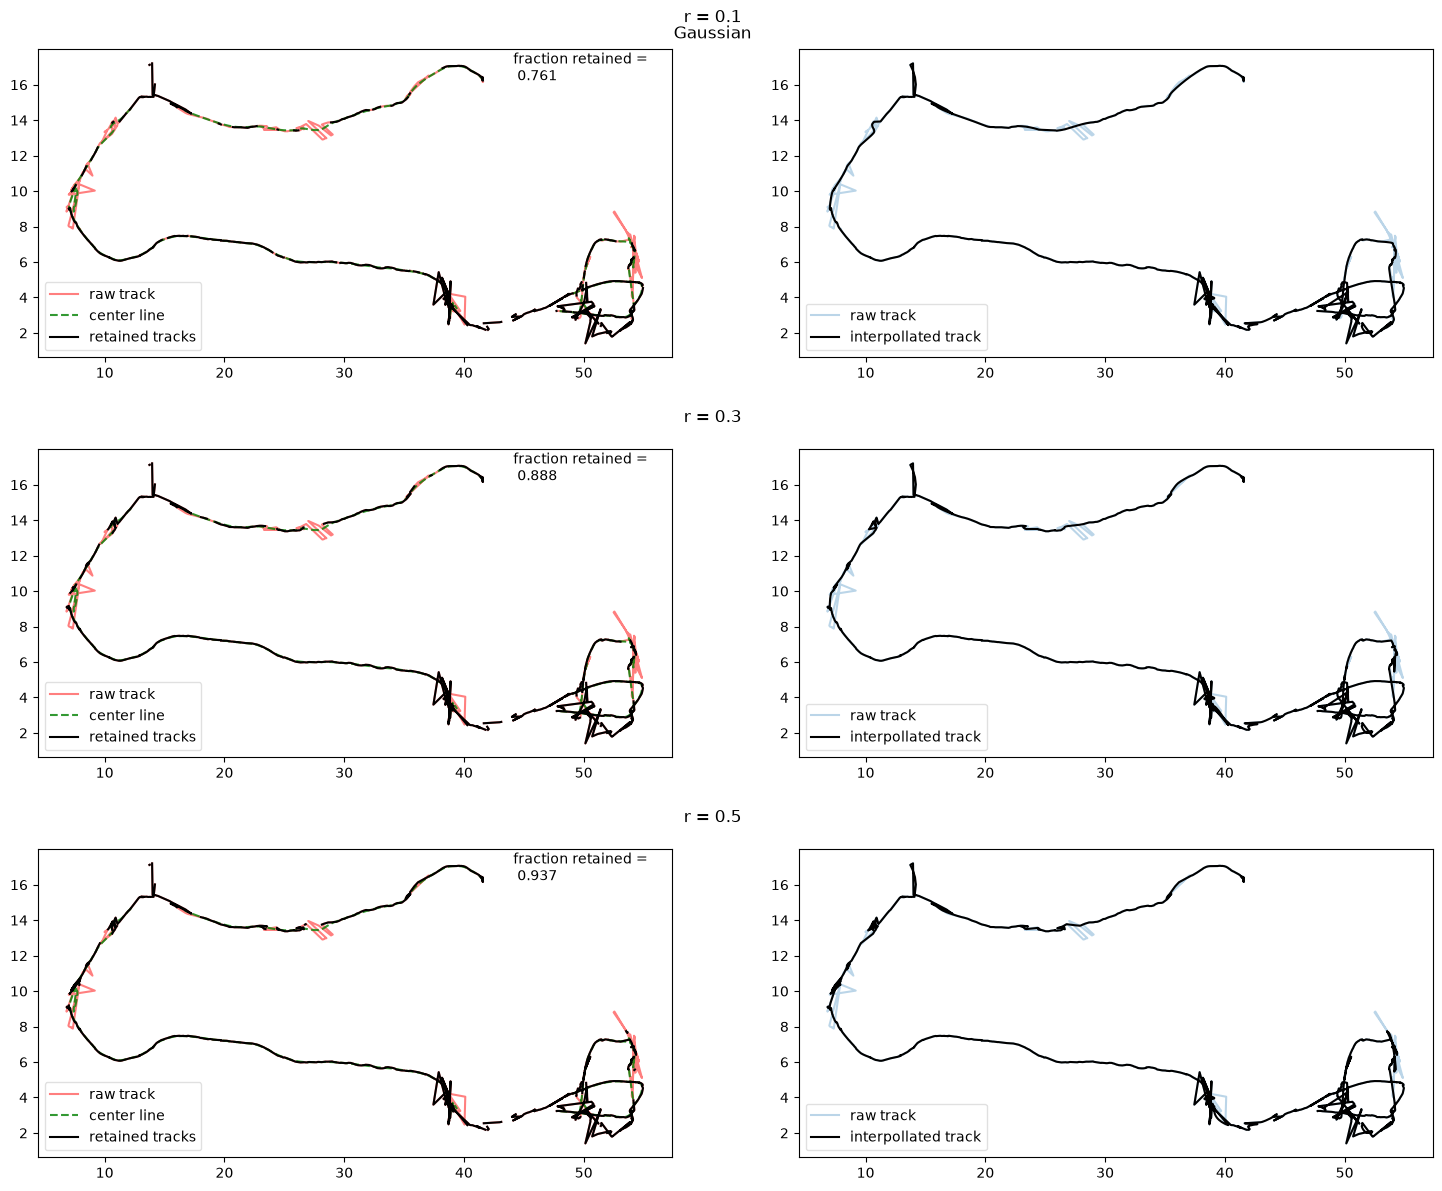

In [26]:
# Gaussian smoothening
from scipy.ndimage import gaussian_filter1d

sigma = 5
med_filtered_x = gaussian_filter1d(x, sigma=sigma)
med_filtered_y = gaussian_filter1d(y, sigma=sigma)

r_all = [0.1, 0.3, 0.5]

fig = plt.figure(figsize=(18,12))
subfigs = fig.subfigures(len(r_all), 1)

gaussian_dist_cl = np.zeros(len(x))
fig.suptitle("Gaussian")

for i, subfig in enumerate(subfigs):
    r = r_all[i]
    center_line = np.vstack((med_filtered_x, med_filtered_y))
    clean_pos = np.vstack((x, y))

    dist_from_cl = clean_pos - center_line
    dist_from_cl = np.linalg.norm(dist_from_cl, axis=0, ord=2)
    gaussian_dist_cl = dist_from_cl
    
    out_of_blanket_mask = (dist_from_cl >= r)
    out_of_blanket_mask[0], out_of_blanket_mask[-1] = False, False

    curr_x_anchors = x.copy()
    curr_y_anchors = y.copy()

    curr_x_anchors[out_of_blanket_mask] = np.nan
    curr_y_anchors[out_of_blanket_mask] = np.nan

    subfig.suptitle(f"r = {r}")
    ax = subfig.subplots(nrows=1, ncols=2)
    fraction_of_track_retained = 1 - out_of_blanket_mask.sum()/len(x)

    ax[0].plot(x, y, color='red', alpha=0.5, label='raw track')
    ax[0].plot(med_filtered_x, med_filtered_y, 'g--', alpha=0.8, label="center line")
    ax[0].plot(curr_x_anchors, curr_y_anchors, color='black', label="retained tracks")
    ax[0].legend(loc="lower left", framealpha=0.6)
    ax[0].text(0.75, 0.9, f"fraction retained = \n {round(fraction_of_track_retained,3)}", transform=ax[0].transAxes)
               
    x_interp = pd.Series(curr_x_anchors).interpolate(method='pchip').to_numpy()
    y_interp = pd.Series(curr_y_anchors).interpolate(method='pchip').to_numpy()

    ax[1].plot(x, y, alpha=0.3,label= "raw track")
    ax[1].plot(x_interp, y_interp, color='black', label="interpollated track")
    ax[1].legend(loc="lower left", framealpha=0.6)

# plt.tight_layout()
plt.show()

In [ ]:
# # man we need a function to plot these many things
# def blanket(x, y, method, r, k=23, sigma=5):
#     if method == "median":
#         smooth_x = pd.Series(x).rolling(window=k, min_periods=1, center=True).median().to_numpy()
#         smooth_y = pd.Series(y).rolling(window=k, min_periods=1, center=True).median().to_numpy()
#     elif method == "mean":
#         smooth_x = pd.Series(x).rolling(window=k, min_periods=1, center=True).mean().to_numpy()
#         smooth_y = pd.Series(y).rolling(window=k, min_periods=1, center=True).mean().to_numpy()
#     elif method == "gaussian":
#         smooth_x = gaussian_filter1d(x, sigma=sigma)
#         smooth_y = gaussian_filter1d(y, sigma=sigma)
#         # smooth_x = pd.Series(x).rolling(window=k, win_type="gaussian", min_periods=1, center=True).mean(std=sigma).to_numpy()
#         # smooth_y = pd.Series(y).rolling(window=k, win_type="gaussian", min_periods=1, center=True).mean(std=sigma).to_numpy()
        
#     center_line = np.vstack((smooth_x, smooth_y))
#     clean_pos = np.vstack((x, y))

#     dist_from_cl = clean_pos - center_line
#     dist_from_cl = np.linalg.norm(dist_from_cl, axis=0, ord=2)
    
#     out_of_blanket_mask = (dist_from_cl >= r)
#     out_of_blanket_mask[0], out_of_blanket_mask[-1] = False, False

#     curr_x_anchors = x.copy()
#     curr_y_anchors = y.copy()

#     curr_x_anchors[out_of_blanket_mask] = np.nan
#     curr_y_anchors[out_of_blanket_mask] = np.nan

#     return curr_x_anchors, curr_y_anchors, smooth_x, smooth_y

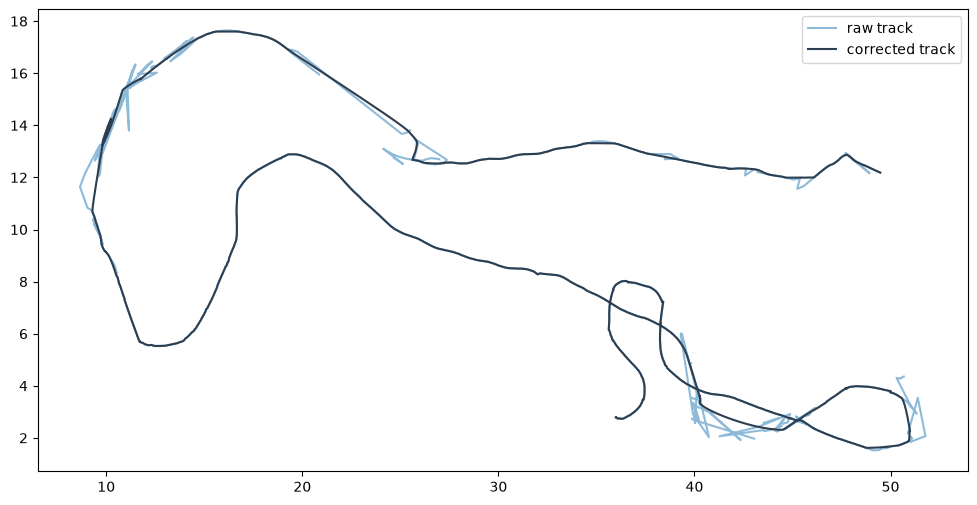

In [37]:
from cleaning_pipeline_functions import blanket
x_med_corrected, y_med_corrected, x_med_smooth, y_med_smooth, frac = blanket(x, y, method="median")
# x_gaussian_corrected, y_gaussian_corrected, x_gaussian_smooth, y_gaussian_smooth = blanket(x, y, method="gaussian", r=0.3, sigma=10)

x_med_interp = pd.Series(x_med_corrected).interpolate(method='pchip').to_numpy()
y_med_interp = pd.Series(y_med_corrected).interpolate(method='pchip').to_numpy()
# x_gaussian_interp = pd.Series(x_gaussian_corrected).interpolate(method='pchip').to_numpy()
# y_gaussian_interp = pd.Series(y_gaussian_corrected).interpolate(method='pchip').to_numpy()

plt.figure(figsize=(12, 6))
plt.plot(x, y, alpha = 0.5, label='raw track')
plt.plot(x_med_interp, y_med_interp, color='#2C3E50', label='corrected track')
# plt.plot(x_gaussian_interp, y_gaussian_interp, color='#E74C3C', alpha=0.6, label='gaussian')
plt.legend()

In [29]:
print(np.nanpercentile(gaussian_dist_cl,75))

0.123121046


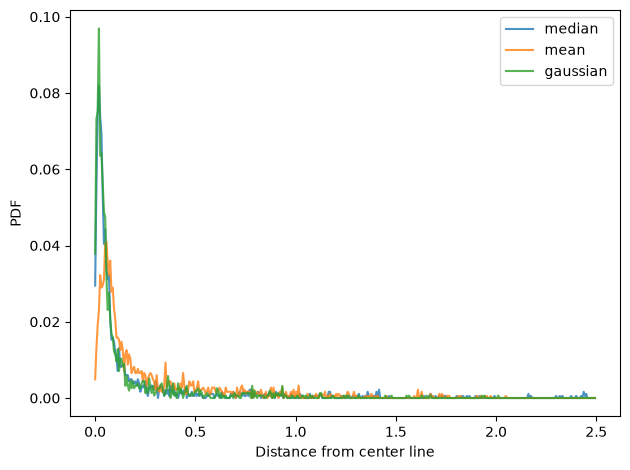

In [42]:
from scipy import stats
edges = np.linspace(0, 2.5, 400)
# fig, ax = plt.subplots(1,3, figsize=(15, 4))
arrays = [median_dist_cl, mean_dist_cl, gaussian_dist_cl]
labels = ['median', 'mean', 'gaussian']
for i in range(3):
# print(r)
    counts, _ = np.histogram(arrays[i], bins=edges)
    prop = counts/counts.sum()
    plt.plot(edges[:-1], prop, label=labels[i], alpha=0.8)
    # print(labels[i], stats.mode(counts))
# plt.title("Mean")
plt.ylabel('PDF')
plt.xlabel('Distance from center line')
plt.tight_layout()
plt.legend()
plt.show()


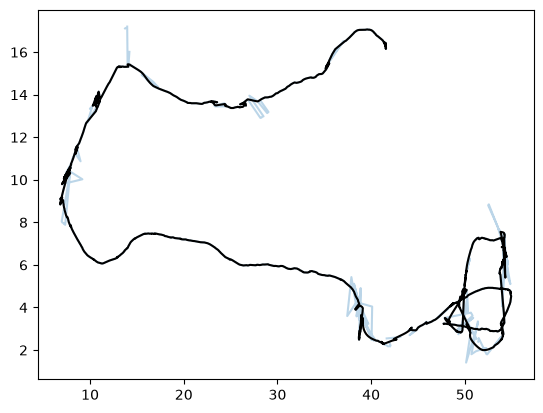

In [50]:
# %matplotlib widget
x_interp = pd.Series(x_anchors).interpolate(method='pchip').to_numpy()
y_interp = pd.Series(y_anchors).interpolate(method='pchip').to_numpy()
plt.close()
plt.plot(x, y, alpha=0.3)
plt.plot(x_interp_med, y_interp_med, color='black')
plt.show()


<Axes: >

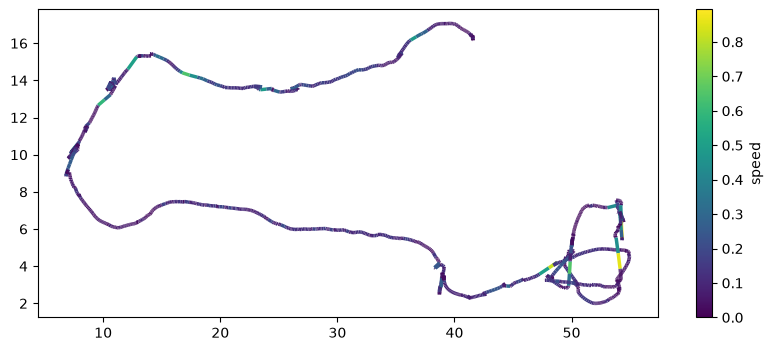

In [52]:
from cleaning_pipeline_functions import speedy_trail
vel_x = np.gradient(x_interp_med)
vel_y = np.gradient(y_interp_med)

vel = np.zeros((x.shape[0], 2))

vel[:,0] = vel_x
vel[:,1] = vel_y

interp_speed = np.linalg.norm(vel, axis=1, ord=2)

speedy_trail(x_interp_med, y_interp_med, interp_speed)